# Real World Classification

## Load data

Import the necessary libraries

In [46]:
# If you do not use colab. You should install these packages.
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install graphviz

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [48]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [49]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    print(df.isnull().sum())
    
    stats_before = df[feature_cols].agg(['median', 'std'])
    print("--- Median and Standard Deviation before imputation---\n", stats_before)

    impute = KNNImputer(n_neighbors=5)
    df[feature_cols] = impute.fit_transform(df[feature_cols])
    
    stats_after = df[feature_cols].agg(['median', 'std'])
    print("---Median and Standard Deviation after imputation---\n",stats_after)
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

Id                        0
SepalLengthCm            28
SepalWidthCm             57
PetalLengthCm           150
PetalWidthCm             22
                       ... 
ThermalResponseIndex      0
UVExposureIndex           0
WindStressIndex           0
GrowthVigorIndex          0
Species                   0
Length: 72, dtype: int64
--- Median and Standard Deviation before imputation---
         SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
median       6.300000      2.900000       5.085612      1.600000   
std          1.037115      0.389564       1.582807      0.706689   

        BranchLength    AvgDust  SepalLengthMajorAxis  SepalLengthMinorAxis  \
median     16.300000  44.000000              6.316422              6.310315   
std         1.035228  30.032428              1.009859              1.043500   

        SepalLengthElongation  SepalLengthCompactness  ...  LeafShadowIndex  \
median               6.320980                6.332139  ...         0.028643   
std       

In [50]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

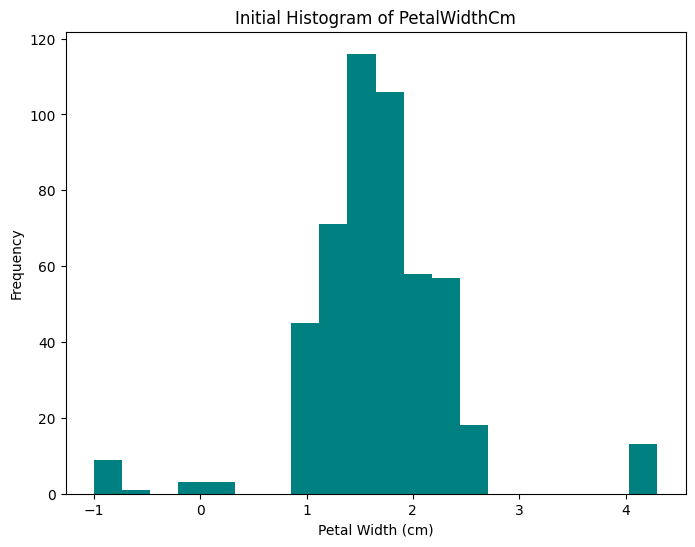

Id                       0
SepalLengthCm            0
SepalWidthCm             0
PetalLengthCm            0
PetalWidthCm            10
                        ..
ThermalResponseIndex     0
UVExposureIndex          0
WindStressIndex          0
GrowthVigorIndex         0
Species                  0
Length: 72, dtype: int64
--- Median and Standard Deviation before imputation---
         SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
median       6.300000      2.900000       5.035683      1.700000   
std          1.009275      0.372434       1.514955      0.600218   

        BranchLength    AvgDust  SepalLengthMajorAxis  SepalLengthMinorAxis  \
median     16.300000  44.000000              6.316422              6.310315   
std         1.011012  30.032428              1.009859              1.043500   

        SepalLengthElongation  SepalLengthCompactness  ...  LeafShadowIndex  \
median               6.320980                6.332139  ...         0.028643   
std                  

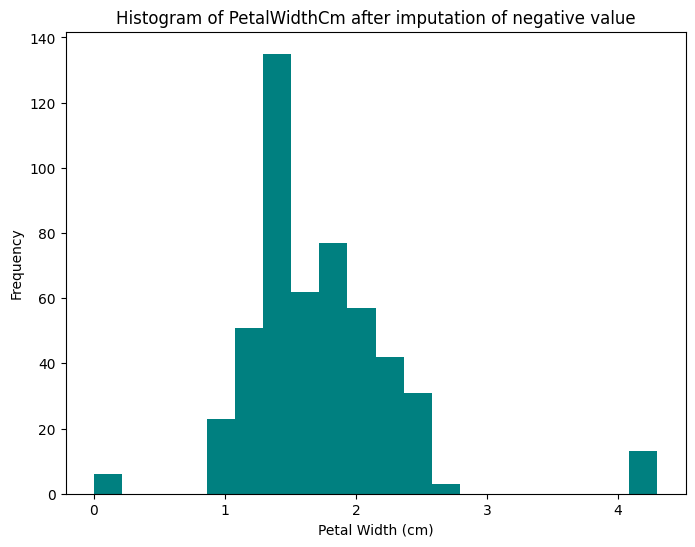

Largest Positive Correlation: PetalWidthCompactness (0.8824)

Top 5 Strongest Negative Correlations:
SepalGlossIndex         -0.123562
IrisVenationSharpness   -0.083020
SepalTextureIndex       -0.057247
SepalThicknessIndex     -0.051732
PollenResidueIndex      -0.051082
dtype: float64


C:\Users\wirad\AppData\Local\Temp\ipykernel_19468\86427258.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=selected_features, patch_artist=True)


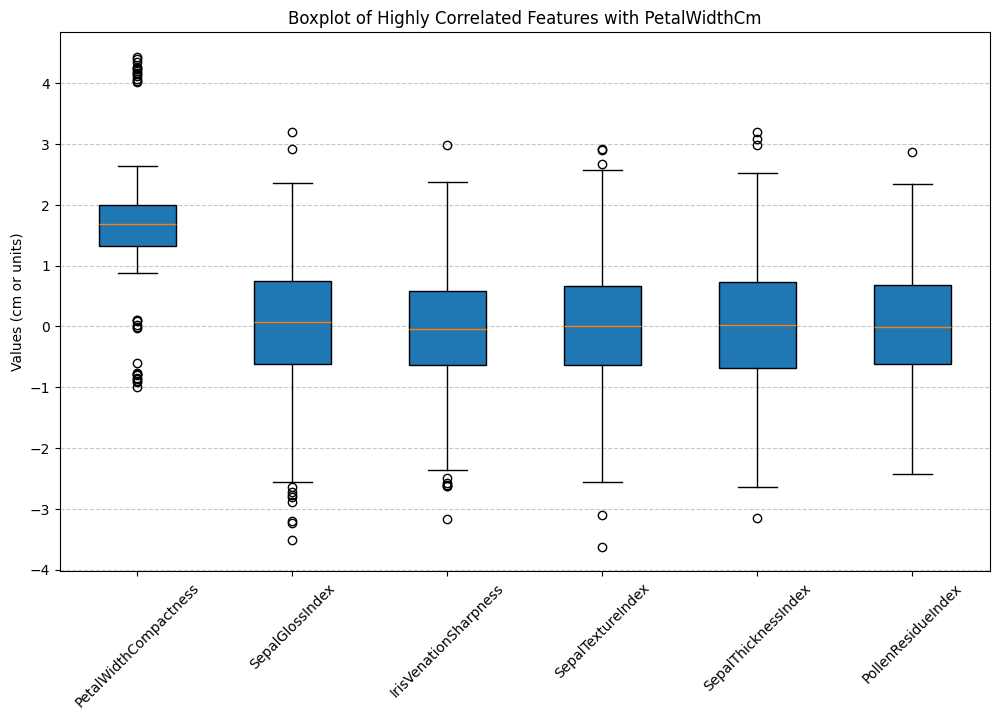

In [51]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration
plt.figure(figsize=(8, 6))
plt.hist(df['PetalWidthCm'], bins=20, color='teal')
plt.title('Initial Histogram of PetalWidthCm')
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency')
plt.show()

df.loc[df['PetalWidthCm'] < 0, 'PetalWidthCm'] = pd.NA
df, feature_cols = data_preprocessing(df)

plt.figure(figsize=(8, 6))
plt.hist(df['PetalWidthCm'], bins=20, color='teal')
plt.title('Histogram of PetalWidthCm after imputation of negative value')
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency')
plt.show()

target = df['PetalWidthCm']
other_features = [c for c in feature_cols if c != 'PetalWidthCm']
X = df[other_features]

correlations = r_regression(X, target)
corr_series = pd.Series(correlations, index=other_features)

top_positive_feature = corr_series.idxmax()
print(f"Largest Positive Correlation: {top_positive_feature} ({corr_series.max():.4f})")

top_negative_features = corr_series.sort_values().head(5)
print("\nTop 5 Strongest Negative Correlations:")
print(top_negative_features)

selected_features = [top_positive_feature] + top_negative_features.index.tolist()
data_to_plot = [df[col] for col in selected_features]

plt.figure(figsize=(12, 7))
plt.boxplot(data_to_plot, labels=selected_features, patch_artist=True)
plt.title('Boxplot of Highly Correlated Features with PetalWidthCm')
plt.ylabel('Values (cm or units)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Model Training

### Prepare the data

In [52]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.325581,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.348837,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.348837,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.302326,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.348837,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.615820667562784, Val loss:0.6361244996868856
100. Training loss: 0.5923708105982602, Val loss:0.6194070172829922
150. Training loss: 0.5736724935953942, Val loss:0.6064420481009799
200. Training loss: 0.558423621216325, Val loss:0.5962343136294411
250. Training loss: 0.5457446499629817, Val loss:0.5881006148848515
300. Training loss: 0.5350271425209754, Val loss:0.5815593063368372
350. Training loss: 0.5258397417669571, Val loss:0.5762621839755742
400. Training loss: 0.5178692659322308, Val loss:0.5719516996293694
450. Training loss: 0.510883202641184, Val loss:0.5684334591163569
500. Training loss: 0.504705358337846, Val loss:0.5655581108916478
550. Training loss: 0.4991997180756495, Val loss:0.5632091283517731
600. Training loss: 0.49425952194977163, Val loss:0.5612943753656362
650. Training loss: 0.48979971967395874, Val loss:0.5597401558699628
700. Training loss: 0.48575165527028913, Val loss:0.5584869308690182
750. Training loss: 0.4820592522544682, Val loss:0

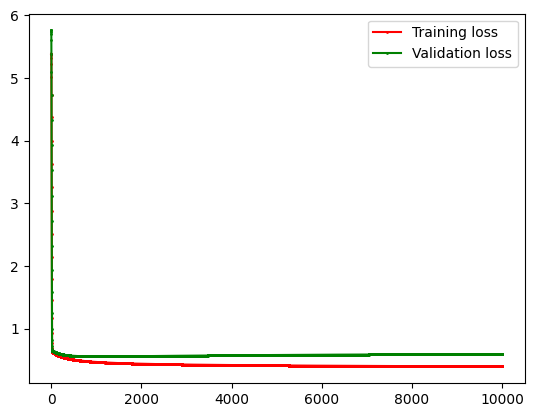

Model parameters (weights): [[-2.98333362e+00]
 [ 8.03499544e-01]
 [ 2.98101140e-01]
 [-8.64121149e-01]
 [ 5.69271102e+00]
 [ 6.42306881e-03]
 [ 1.63594980e-01]
 [-3.37244658e-03]
 [ 2.11870849e-01]
 [ 1.87725479e+00]
 [ 8.76830638e-01]
 [ 7.74555231e-01]
 [ 1.12487894e+00]
 [ 1.80803364e-01]
 [-9.67034903e-01]
 [-1.13560605e-01]
 [ 1.59670314e+00]
 [ 6.47670136e-01]
 [ 1.03924114e-01]
 [ 1.06928112e-01]
 [ 2.05495606e-01]
 [ 4.28123629e-01]
 [-1.93263929e-01]
 [ 5.87514515e-01]
 [ 3.72575937e-01]
 [ 1.44294007e+00]
 [ 1.14743638e+00]
 [ 1.10755273e+00]
 [ 1.34589190e+00]
 [ 1.16408259e+00]
 [ 1.11808770e+00]
 [-2.24238505e+00]
 [ 1.40202279e+00]
 [-4.05060209e-01]
 [ 3.25002524e-01]
 [-1.47413014e+00]
 [ 6.53672488e-01]
 [-1.03647955e+00]
 [-3.00988157e+00]
 [-4.78684602e-01]
 [-1.22584361e+00]
 [-3.97635170e-01]
 [-9.64957737e-01]
 [-1.19770227e+00]
 [ 5.68274773e-01]
 [ 2.69912270e-02]
 [-6.40689821e-02]
 [ 4.49759013e-01]
 [-5.62857419e-01]
 [-6.41081196e-01]
 [-6.37193722e-01]
 [ 

In [53]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='', reg_lambda=0.0)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.7467
Precision : 0.7436
Recall    : 0.7632
F1-score  : 0.7532


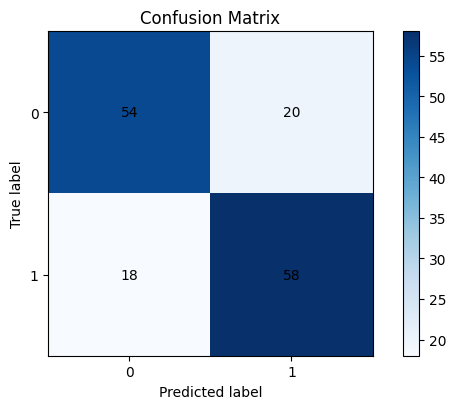

{'Accuracy': 0.7466666666666667,
 'Precision': 0.7435897435897436,
 'Recall': 0.7631578947368421,
 'F1-score': 0.7532467532467533}

In [54]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)

50. Training loss: 0.6158292405465453, Val loss:0.6361284313655667
100. Training loss: 0.5923901699426949, Val loss:0.619415755095808
150. Training loss: 0.5737036693127996, Val loss:0.6064555491692752
200. Training loss: 0.5584670027312886, Val loss:0.5962519946035054
250. Training loss: 0.545800308386052, Val loss:0.5881215959749985
300. Training loss: 0.5350949826990722, Val loss:0.5815825479171924
350. Training loss: 0.5259195756535272, Val loss:0.5762865675352641
400. Training loss: 0.5179608497679392, Val loss:0.571976078198424
450. Training loss: 0.5109862574545754, Val loss:0.5684566898323365
500. Training loss: 0.5048195826185269, Val loss:0.5655790764201488
550. Training loss: 0.4993247965731411, Val loss:0.5632267509437836
600. Training loss: 0.49439513233023435, Val loss:0.5613076258329255
650. Training loss: 0.4899455377860883, Val loss:0.5597480589492384
700. Training loss: 0.48590735935755425, Val loss:0.5584885679801529
750. Training loss: 0.4822245262885138, Val loss:0

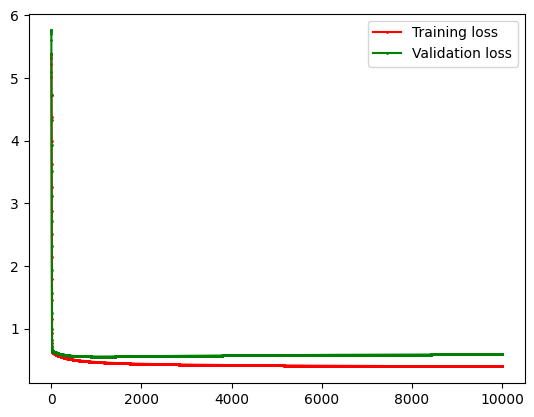

Model parameters (weights): [[-2.87363176]
 [ 0.80100422]
 [ 0.30236356]
 [-0.8364623 ]
 [ 5.54334245]
 [ 0.02853247]
 [ 0.16270897]
 [ 0.01451893]
 [ 0.21852798]
 [ 1.81977965]
 [ 0.85810598]
 [ 0.75205394]
 [ 1.10141349]
 [ 0.16532831]
 [-0.94141934]
 [-0.09568113]
 [ 1.52972512]
 [ 0.62762467]
 [ 0.11286331]
 [ 0.09921703]
 [ 0.21625233]
 [ 0.43258532]
 [-0.17581694]
 [ 0.57093646]
 [ 0.35338441]
 [ 1.41651217]
 [ 1.14314828]
 [ 1.10177293]
 [ 1.32584046]
 [ 1.16274892]
 [ 1.10901085]
 [-2.18729041]
 [ 1.36336989]
 [-0.39825987]
 [ 0.30999731]
 [-1.42961473]
 [ 0.63684732]
 [-1.01742662]
 [-2.94644496]
 [-0.46951812]
 [-1.20300839]
 [-0.39346842]
 [-0.95522076]
 [-1.1719222 ]
 [ 0.55108973]
 [ 0.00713764]
 [-0.06873365]
 [ 0.42510183]
 [-0.55613536]
 [-0.6319055 ]
 [-0.62414786]
 [ 0.37013771]
 [ 0.14669714]
 [-0.49372941]
 [-0.27780715]
 [ 0.41432159]
 [-0.82111659]
 [-1.20048656]
 [-0.25149803]
 [ 0.62216988]
 [-0.91505677]
 [ 0.71242305]
 [ 0.57181676]
 [-1.49169373]
 [ 0.103829 

In [55]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='l2', reg_lambda=0.01)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.7467
Precision : 0.7436
Recall    : 0.7632
F1-score  : 0.7532


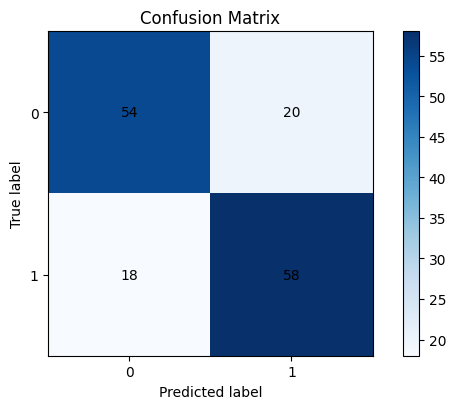

{'Accuracy': 0.7466666666666667,
 'Precision': 0.7435897435897436,
 'Recall': 0.7631578947368421,
 'F1-score': 0.7532467532467533}

In [56]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)

50. Training loss: 0.6166931355789281, Val loss:0.6365450907220154
100. Training loss: 0.5943656011003634, Val loss:0.6203871938043612
150. Training loss: 0.5769150456199068, Val loss:0.6080245102800932
200. Training loss: 0.5629698127747965, Val loss:0.5984046709522198
250. Training loss: 0.5516138146686632, Val loss:0.5908130630136232
300. Training loss: 0.5422182531639187, Val loss:0.5847512047469352
350. Training loss: 0.5343397204141574, Val loss:0.5798627140597828
400. Training loss: 0.5276575509314587, Val loss:0.5758871852509386
450. Training loss: 0.521934472250853, Val loss:0.572630695732752
500. Training loss: 0.5169912906986737, Val loss:0.5699464447405892
550. Training loss: 0.5126902028707395, Val loss:0.5677217194791956
600. Training loss: 0.5089235280089631, Val loss:0.5658689135804443
650. Training loss: 0.5056059265158175, Val loss:0.5643192052455349
700. Training loss: 0.5026689119765152, Val loss:0.5630180219947142
750. Training loss: 0.5000569054790776, Val loss:0.

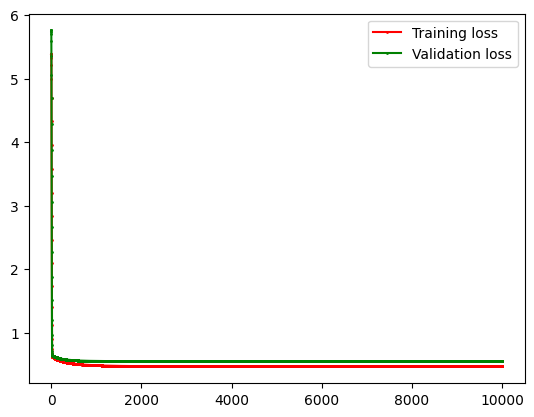

Model parameters (weights): [[-0.66374466]
 [ 0.4895657 ]
 [ 0.1638266 ]
 [-0.03539941]
 [ 1.616059  ]
 [ 0.32150656]
 [ 0.16783524]
 [ 0.29479174]
 [ 0.33328327]
 [ 0.52475345]
 [ 0.40405219]
 [ 0.38327131]
 [ 0.47526209]
 [ 0.0186102 ]
 [-0.14607956]
 [ 0.09793643]
 [ 0.23048511]
 [ 0.17299588]
 [ 0.12448286]
 [ 0.11051986]
 [ 0.20971018]
 [ 0.26229156]
 [ 0.13171332]
 [ 0.22683439]
 [ 0.1481139 ]
 [ 0.78299119]
 [ 0.79838972]
 [ 0.80194662]
 [ 0.81526761]
 [ 0.83714134]
 [ 0.80040135]
 [-0.70200113]
 [ 0.31845551]
 [-0.23195665]
 [ 0.00218231]
 [-0.36427075]
 [ 0.0903499 ]
 [-0.4434033 ]
 [-1.16584327]
 [-0.19323217]
 [-0.50246854]
 [-0.21433999]
 [-0.55835603]
 [-0.42884722]
 [ 0.10788498]
 [-0.23505956]
 [-0.18310318]
 [-0.11707924]
 [-0.33467912]
 [-0.34809476]
 [-0.23474945]
 [-0.09118832]
 [-0.08192153]
 [-0.28558847]
 [-0.11161117]
 [ 0.04480236]
 [-0.41135375]
 [-0.57064148]
 [-0.24231396]
 [-0.07708892]
 [-0.5352172 ]
 [ 0.10764362]
 [ 0.17936746]
 [-0.61762899]
 [-0.1861027

In [57]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='l2', reg_lambda=1)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.7533
Precision : 0.7407
Recall    : 0.7895
F1-score  : 0.7643


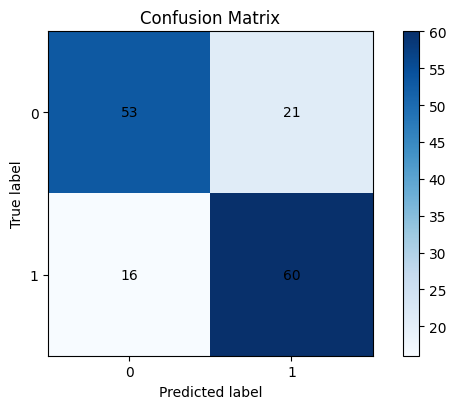

{'Accuracy': 0.7533333333333333,
 'Precision': 0.7407407407407407,
 'Recall': 0.7894736842105263,
 'F1-score': 0.7643312101910829}

In [58]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)

50. Training loss: 0.6731240060292984, Val loss:0.6821810676033462
100. Training loss: 0.6741113797254956, Val loss:0.6832129012347969
150. Training loss: 0.6741309809650857, Val loss:0.6832348205210779
200. Training loss: 0.6741313664207471, Val loss:0.6832352838346303
250. Training loss: 0.6741313740107077, Val loss:0.6832352936979501
300. Training loss: 0.6741313741602853, Val loss:0.683235293909422
350. Training loss: 0.6741313741632328, Val loss:0.6832352939139863
400. Training loss: 0.6741313741632908, Val loss:0.6832352939140856
450. Training loss: 0.6741313741632918, Val loss:0.6832352939140875
500. Training loss: 0.6741313741632918, Val loss:0.6832352939140878
550. Training loss: 0.6741313741632919, Val loss:0.6832352939140878
600. Training loss: 0.6741313741632919, Val loss:0.6832352939140878
650. Training loss: 0.6741313741632919, Val loss:0.6832352939140878
700. Training loss: 0.6741313741632919, Val loss:0.6832352939140878
750. Training loss: 0.6741313741632919, Val loss:0

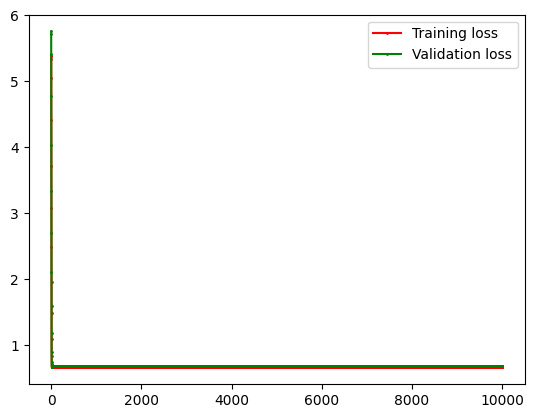

Model parameters (weights): [[-0.01250013]
 [ 0.02227405]
 [ 0.00727671]
 [ 0.02153773]
 [ 0.04705585]
 [ 0.01868095]
 [ 0.01763792]
 [ 0.01788581]
 [ 0.0192333 ]
 [ 0.02027247]
 [ 0.01913917]
 [ 0.020134  ]
 [ 0.02094317]
 [ 0.0045549 ]
 [ 0.00309324]
 [ 0.006028  ]
 [ 0.00701923]
 [ 0.00739245]
 [ 0.00624007]
 [ 0.023216  ]
 [ 0.02379543]
 [ 0.02559424]
 [ 0.02384981]
 [ 0.0251404 ]
 [ 0.02369216]
 [ 0.03458749]
 [ 0.0351866 ]
 [ 0.03658532]
 [ 0.03645456]
 [ 0.03667075]
 [ 0.03666736]
 [-0.01303509]
 [ 0.0045322 ]
 [-0.00646964]
 [-0.00238802]
 [-0.00520335]
 [-0.0033465 ]
 [-0.0124205 ]
 [-0.02754939]
 [-0.00524911]
 [-0.0098419 ]
 [-0.00411469]
 [-0.01538785]
 [-0.00699982]
 [-0.00175236]
 [-0.00552656]
 [-0.00864638]
 [-0.00523256]
 [-0.01144463]
 [-0.00882137]
 [-0.00135956]
 [-0.00755241]
 [-0.00632663]
 [-0.00800218]
 [-0.00209667]
 [-0.00160946]
 [-0.00839608]
 [-0.01317377]
 [-0.00862762]
 [-0.01060535]
 [-0.01524619]
 [-0.0004276 ]
 [ 0.00441994]
 [-0.0125544 ]
 [-0.0094504

In [59]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='l2', reg_lambda=100)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


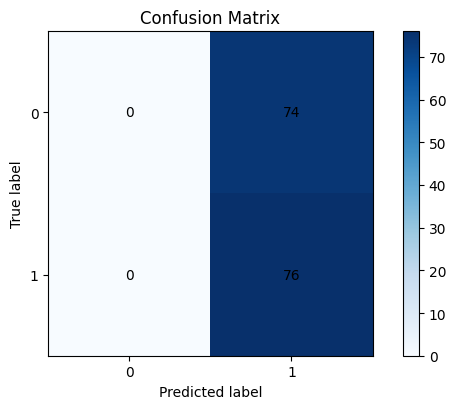

{'Accuracy': 0.5066666666666667,
 'Precision': 0.5066666666666667,
 'Recall': 1.0,
 'F1-score': 0.672566371681416}

In [60]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)